In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("../data/raw/Reddit ADR all/reddit_ADR.txt")
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

## Loading raw data

## Basic stats

In [19]:
# It covers the following:
## data loading
## per-user distribution
## n of unique ADRs
## per-ADR distribution
## frequency visualization
## summary export

In [3]:
df = pd.read_csv(data_path, sep="\t", names=["post_id", "adr"], engine="python").dropna()
df["adr"] = df["adr"].str.lower().str.strip()
print(f"Rows: {len(df)}, Unique users: {df['post_id'].nunique()}")

Rows: 1453, Unique users: 600


In [4]:
complaints_per_user = df.groupby("post_id")["adr"].count()
print("\nComplaints per user:")
print(complaints_per_user.describe())


Complaints per user:
count    600.000000
mean       2.421667
std        2.220078
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       24.000000
Name: adr, dtype: float64


## Visualizing distribution

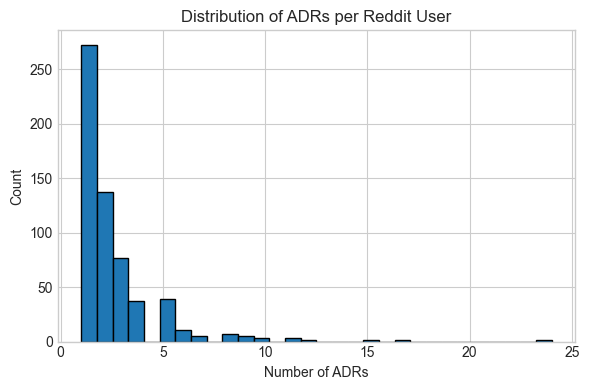

In [5]:
plt.figure(figsize=(6,4))
complaints_per_user.hist(bins=30, edgecolor='black')
plt.title("Distribution of ADRs per Reddit User")
plt.xlabel("Number of ADRs")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "fig_adr_per_user.png", dpi=300)

## Top ADR frequency

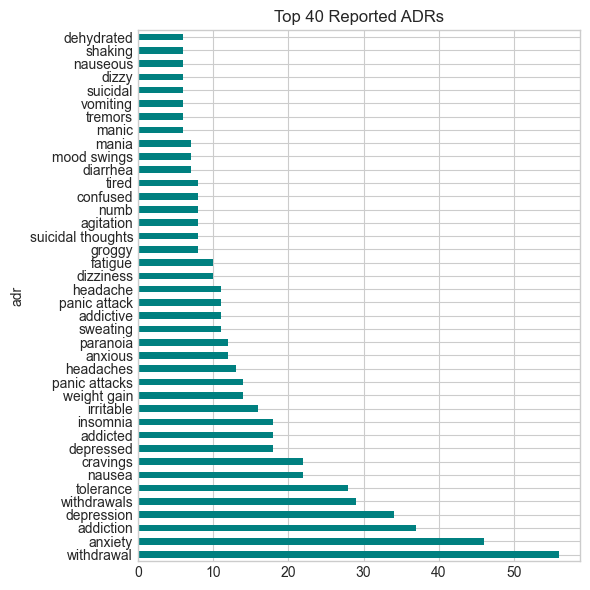

In [9]:
adr_counts = df["adr"].value_counts().head(40)
adr_counts.plot(kind="barh", figsize=(6,6), color="teal")
plt.title("Top 40 Reported ADRs")
plt.tight_layout()
plt.savefig(out_dir / "fig_top_adrs.png", dpi=300)

# n of unique ADRs

In [12]:
n_unique_adrs = df["adr"].nunique()
print(f"\nUnique ADR terms reported: {n_unique_adrs}")


Unique ADR terms reported: 667


## Checking top rarest ones

In [13]:
print("\nLeast common ADRs:")
print(df['adr'].value_counts().tail(10))


Least common ADRs:
adr
emotional blunting              1
clots                           1
hyper hidrosis                  1
nightmares,                     1
feel sick                       1
spotting                        1
fainting                        1
resistant                       1
multiple join deteriorations    1
uncaring                        1
Name: count, dtype: int64


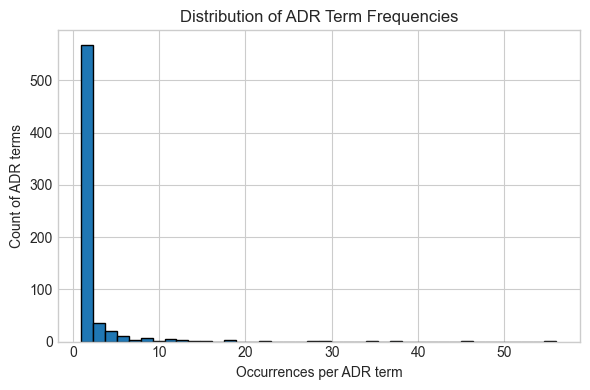

In [16]:
adr_freq = df['adr'].value_counts()
plt.figure(figsize=(6,4))
plt.hist(adr_freq, bins=40, edgecolor='black')
plt.title("Distribution of ADR Term Frequencies")
plt.xlabel("Occurrences per ADR term")
plt.ylabel("Count of ADR terms")
plt.tight_layout()
plt.savefig(out_dir / "fig_adr_frequency_distribution.png", dpi=300)

In [17]:
df.to_csv(out_dir / "reddit_adr_clean.csv", index=False)
print("Saved:", out_dir / "reddit_adr_clean.csv")

adr_summary = pd.DataFrame({
    "n_total_reports": [len(df)],
    "n_unique_adrs": [n_unique_adrs],
    "n_unique_users": [df['post_id'].nunique()],
    "mean_reports_per_user": [df.groupby("post_id")["adr"].count().mean()],
    "median_reports_per_user": [df.groupby("post_id")["adr"].count().median()]
})
adr_summary.to_csv(out_dir / "adr_summary_stats.csv", index=False)
print("Saved:", out_dir / "adr_summary_stats.csv")

Saved: ../data/processed/reddit_adr_clean.csv
Saved: ../data/processed/adr_summary_stats.csv
